# **Email Spam Detection using Machine Learning**

# **Project Overview**

This project aims to build a machine learning model that can classify emails as Spam or Not Spam (Ham) using Natural Language Processing techniques.

## **Objectives**
*   Perform text preprocessing
*   Convert text into numerical features using
*   TF-IDF
*   Train classification models
*   Evaluate performance








# **1. Import Required Libraries**

In this step, we import all necessary libraries required for data analysis, visualization, text preprocessing, and machine learning model building.

In [1]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **2.Load Dataset**

We load the dataset containing labeled email messages. The dataset includes two main columns:


*   Label (Spam/Ham)
*   Message (Email content)






In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# **3.Data Cleaning**

We remove unnecessary columns and rename the remaining columns for better readability and understanding.

In [4]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# **Step 4: Label Encoding**

Convert categorical labels into numerical format:

*   Ham → 0
*   Spam → 1






In [5]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# **5. Exploratory Data Analysis**

We visualize the distribution of spam and non-spam emails to understand the dataset balance.

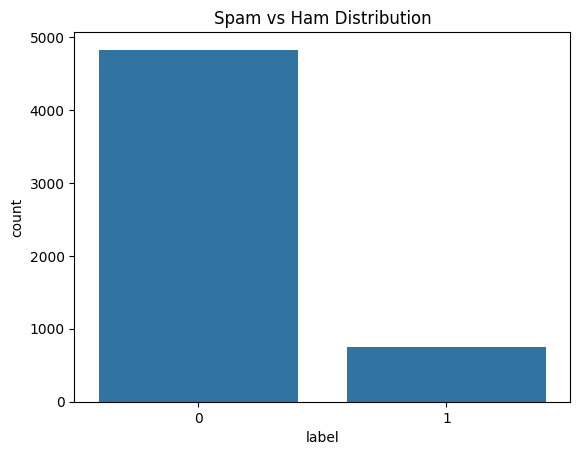

,count
label,
0,4825
1,747


In [6]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

df['label'].value_counts()

# **6: Text Preprocessing**

We clean the text by:

*   Converting to lowercase
*   Removing numbers
*   Removing punctuation
*   Removing extra spaces







In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text

df['message'] = df['message'].apply(clean_text)

# **7. Train-Test Split**

We split the dataset into training and testing sets to evaluate model performance.

In [8]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **8. Feature Extraction (TF-IDF)**

Convert text data into numerical format using TF-IDF, which captures word importance.

In [9]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# **9. Model Training**

We train a Logistic Regression model for binary classification.

In [10]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

LogisticRegression()

# **10. Model Evaluation**

We evaluate model performance using accuracy, classification report, and confusion matrix.

Accuracy: 0.9506726457399103
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



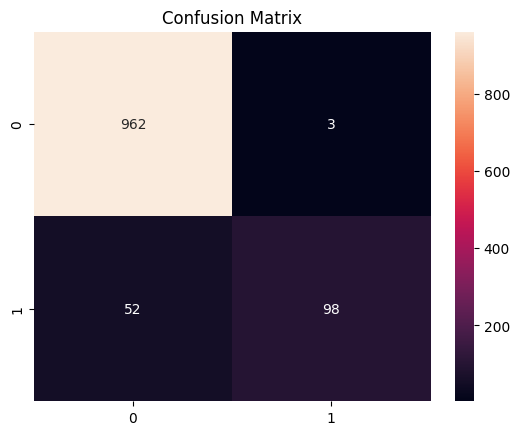

In [11]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# **11. Save Model**

Save the trained model and vectorizer for future use.

In [12]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

# **12: Prediction System**

Create a function to classify new email messages.

In [13]:
def predict_spam(message):
    message = clean_text(message)
    vectorized = vectorizer.transform([message])
    prediction = model.predict(vectorized)

    return "Spam" if prediction[0] == 1 else "Not Spam"

predict_spam("Congratulations! You won a free prize")

'Spam'